In [4]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import welch
from scipy.integrate import simps
from scipy.stats import kurtosis, skew
import pywt

# Set sampling frequency
fs = 256

# --- Feature Functions ---

def spectral_entropy(psd):
    psd_norm = psd / np.sum(psd)
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

def hjorth_params(signal):
    d1 = np.diff(signal)
    d2 = np.diff(d1)
    activity = np.var(signal)
    mobility = np.std(d1) / (np.std(signal) + 1e-12)
    complexity = (np.std(d2) / (np.std(d1) + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def wavelet_entropy(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = np.array([np.sum(c**2) for c in coeffs])
    probs = energies / (np.sum(energies) + 1e-12)
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    return entropy, np.sum(energies)

def frequency_statistics(freqs, psd):
    psd_norm = psd / np.sum(psd)
    mean_freq = np.sum(freqs * psd_norm)
    median_freq = freqs[np.searchsorted(np.cumsum(psd_norm), 0.5)]
    peak_freq = freqs[np.argmax(psd)]
    freq_var = np.sum((freqs - mean_freq) ** 2 * psd_norm)
    avg_freq = np.mean(freqs)
    return mean_freq, median_freq, freq_var, peak_freq, avg_freq

def approx_entropy(signal, m=2, r=0.2):
    N = len(signal)
    r *= np.std(signal)
    def _phi(m):
        x = np.array([signal[i:i + m] for i in range(N - m + 1)])
        C = np.sum(np.max(np.abs(x[:, None] - x[None, :]), axis=2) <= r, axis=0) / (N - m + 1)
        return np.sum(np.log(C + 1e-12)) / (N - m + 1)
    return abs(_phi(m) - _phi(m + 1))

def lempel_ziv_complexity(binary_seq):
    s = ''.join(str(int(i)) for i in binary_seq)
    i, l, k, c = 0, 1, 1, 1
    n = len(s)
    while True:
        if i + k == n:
            c += 1
            break
        if s[i:i + k] == s[l:l + k]:
            k += 1
        else:
            if k > 1:
                i += 1
                k -= 1
            else:
                c += 1
                l += 1
                i = 0
                k = 1
        if l + k > n:
            c += 1
            break
    return c / np.log2(n + 1)

# --- Feature Extractor for One Trial (averaged over 64 channels) ---

def extract_mean_features(trial):  # trial shape: (64, 640)
    feature_matrix = []
    for ch in trial:
        freqs, psd = welch(ch, fs=fs)

        # Time-domain features
        mean = np.mean(ch)
        std = np.std(ch)
        sk = skew(ch)
        kurt = kurtosis(ch)
        rms = np.sqrt(np.mean(ch**2))
        ptp = np.ptp(ch)

        # Hjorth features
        act, mob, comp = hjorth_params(ch)

        # Spectral features
        spec_ent = spectral_entropy(psd)
        total_power = simps(psd, freqs)
        mean_f, med_f, var_f, peak_f, avg_f = frequency_statistics(freqs, psd)

        # Wavelet features
        wave_ent, coeff_energy = wavelet_entropy(ch)

        # Approximate Entropy
        ap_en = approx_entropy(ch)

        # Lempel-Ziv Complexity (on binarized signal)
        bin_signal = ch > np.mean(ch)
        lzc = lempel_ziv_complexity(bin_signal)

        # Combine features
        features = [
            mean, std, sk, kurt, rms, ptp,
            act, mob, comp,
            spec_ent, total_power, wave_ent, coeff_energy,
            med_f, mean_f, var_f, peak_f, avg_f,
            ap_en, lzc
        ]
        feature_matrix.append(features)

    return np.mean(np.array(feature_matrix), axis=0)  # shape: (21,)

# --- Load EEG Data and Process All Trials ---

mat_path = "/Users/aryanjaswal/Projects/IMAGINE MAT/WITH OVERLAP/3 sec/data 3sec/cooperate_combined_3s_win_1s_step.mat"
mat_key = "eeg_data_wrt_task_rep_no_eog_256Hz_last_beep"

data = loadmat(mat_path)
eeg_data = data[mat_key]  # shape: (8, 200)

all_mean_features = []

for i in range(eeg_data.shape[0]):
    for j in range(eeg_data.shape[1]):
        trial = eeg_data[i, j]  # shape: (64, 640)
        trial_feats = extract_mean_features(trial)
        all_mean_features.append(trial_feats)

X = np.array(all_mean_features)  # shape: (1600, 21)
print("✅ Final mean feature matrix shape:", X.shape)

# --- Save to CSV with Feature Labels ---

feature_names = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'peak_to_peak',
    'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity',
    'spectral_entropy', 'total_power', 'wavelet_entropy', 'coeff_energy',
    'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency', 'average_frequency',
    'approximate_entropy', 'lempel_ziv_complexity'
]

csv_path = "cooperate_features.csv"
df = pd.DataFrame(X, columns=feature_names)
df.to_csv(csv_path, index=False)

print(f"✅ Mean features saved to: {csv_path}")

/var/folders/jg/v0bbfb4d6z31kv3sqwt32tr40000gn/T/ipykernel_4426/2830315493.py:95: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  total_power = simps(psd, freqs)


✅ Final mean feature matrix shape: (1800, 20)
✅ Mean features saved to: cooperate_features.csv


In [12]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/new features/independent_features.csv", header=None)

# Add '0' as the last column
df['label'] = 8

# Save the updated CSV
df.to_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/new features/independent_features.csv", index=False, header=False)

In [13]:
import pandas as pd

# List your CSV files here
file_list = ["/Users/aryanjaswal/Projects/IMAGINE MAT/new features/a_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/i_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/u_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/out_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/in_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/up_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/cooperate_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/independent_features.csv"
            ]  # Replace with actual file names

all_labels = []

for file in file_list:
    df = pd.read_csv(file, header=None, skiprows=1)  # Skip header row
    last_col = df.iloc[:, -1]
    all_labels.extend(last_col.tolist())

# Convert to DataFrame and add "label" as first cell
label_df = pd.DataFrame(all_labels, columns=["label"])

# Save to CSV with header
label_df.to_csv("new_labels.csv", index=False)

In [14]:
import pandas as pd

# List your CSV files directly
csv_files = ["/Users/aryanjaswal/Projects/IMAGINE MAT/new features/a_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/i_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/u_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/out_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/in_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/up_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/cooperate_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/new features/independent_features.csv"
            ] 

# List to store processed DataFrames
df_list = []

# Loop through each file
for file in csv_files:
    df = pd.read_csv(file)
    if df.columns[-1] == "5":
        df.drop("5", axis=1, inplace=True)  # Remove the column explicitly by label
    else:
        df.drop(df.columns[-1], axis=1, inplace=True)  # Fallback: drop last column
    df_list.append(df)

# Combine all dataframes vertically
combined_df = pd.concat(df_list, ignore_index=True)

# Save to a new CSV file
combined_df.to_csv('new_combined.csv', index=False)

print("Combined CSV saved as 'combined.csv' without the last column '5'")

Combined CSV saved as 'combined.csv' without the last column '5'



===== Random Forest =====
Fold 1: Accuracy = 0.3370
Fold 2: Accuracy = 0.3698
Fold 3: Accuracy = 0.3586
Fold 4: Accuracy = 0.3617
Fold 5: Accuracy = 0.3685
Fold 6: Accuracy = 0.3463
Fold 7: Accuracy = 0.3679
Fold 8: Accuracy = 0.3580
Fold 9: Accuracy = 0.3364
Fold 10: Accuracy = 0.3623
Average Accuracy = 0.3567

===== Decision Tree =====
Fold 1: Accuracy = 0.2494
Fold 2: Accuracy = 0.2704
Fold 3: Accuracy = 0.2630
Fold 4: Accuracy = 0.2451
Fold 5: Accuracy = 0.2543
Fold 6: Accuracy = 0.2494
Fold 7: Accuracy = 0.2481
Fold 8: Accuracy = 0.2870
Fold 9: Accuracy = 0.2475
Fold 10: Accuracy = 0.2685
Average Accuracy = 0.2583

===== Gradient Boosting =====
Fold 1: Accuracy = 0.2716
Fold 2: Accuracy = 0.3167
Fold 3: Accuracy = 0.3037
Fold 4: Accuracy = 0.3111
Fold 5: Accuracy = 0.3228
Fold 6: Accuracy = 0.2963
Fold 7: Accuracy = 0.3111
Fold 8: Accuracy = 0.3006
Fold 9: Accuracy = 0.2889
Fold 10: Accuracy = 0.3167
Average Accuracy = 0.3040


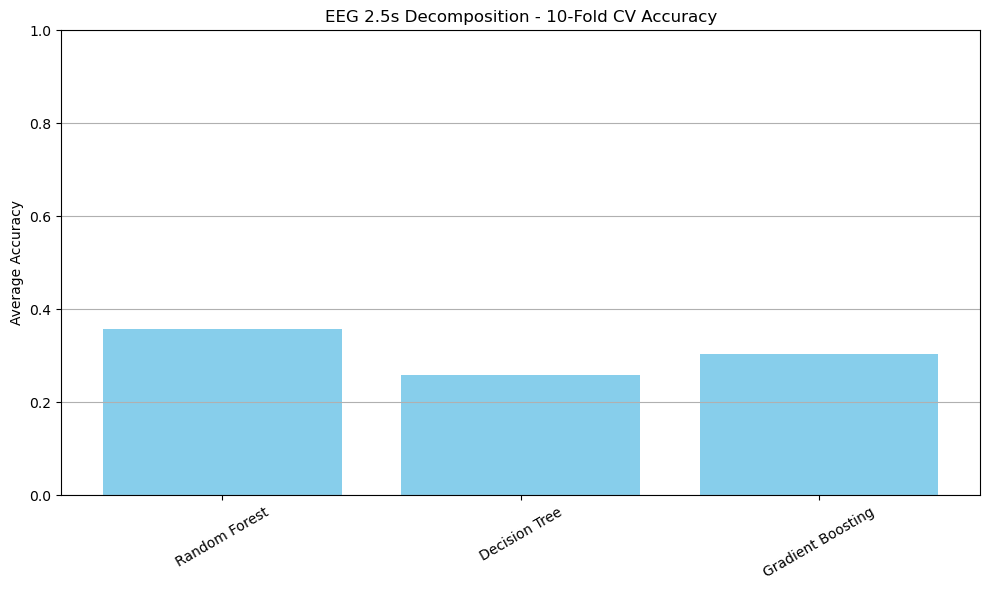

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/new features/new_combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/new features/new_labels.csv', header=None, skiprows=1).squeeze()

# Feature scaling - improves SVM, KNN, etc.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models (with better tuned hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    # Optional: Add SVM or Logistic Regression with tuning
    
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from collections import Counter

# Load the data
features_df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/new features/new_combined.csv")
labels_df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/new features/new_labels.csv")
y = labels_df.iloc[:, -1]  # assuming last column is label
X = features_df

# Scale features for some methods
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Store top features
selected_features = {}

# 1. Variance Threshold
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)
features_vt = X.columns[vt.get_support()]
selected_features['VarianceThreshold'] = list(features_vt)

# 2. SelectKBest with Chi2
chi2_selector = SelectKBest(score_func=chi2, k=10)
X_kbest = chi2_selector.fit_transform(X_scaled, y)
features_kbest = X.columns[chi2_selector.get_support()]
selected_features['Chi2_SelectKBest'] = list(features_kbest)

# 3. Recursive Feature Elimination (RFE) with Logistic Regression
model_lr = LogisticRegression(solver='liblinear')
rfe = RFE(model_lr, n_features_to_select=10)
rfe.fit(X_scaled, y)
features_rfe = X.columns[rfe.support_]
selected_features['RFE'] = list(features_rfe)

# 4. Random Forest Feature Importance
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X, y)
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
features_rf = X.columns[indices]
selected_features['RandomForest'] = list(features_rf)

# 5. Mutual Information
mi = mutual_info_classif(X_scaled, y)
mi_indices = np.argsort(mi)[::-1][:10]
features_mi = X.columns[mi_indices]
selected_features['MutualInformation'] = list(features_mi)

# Display selected features from each method
print("\nSelected features from each technique:")
for method, feats in selected_features.items():
    print(f"{method}: {feats}")

# Count frequency of each feature across all methods
all_selected = sum(selected_features.values(), [])
feature_counts = Counter(all_selected)
print("\nMost frequently selected features (by count):")
for feat, count in feature_counts.most_common():
    print(f"{feat}: {count} times")

# Top common features
top_common = [feat for feat, count in feature_counts.items() if count >= 3]
print("\n✅ Final recommended features (appeared in ≥ 3 techniques):")
print(top_common)


Selected features from each technique:
VarianceThreshold: ['mean', 'std', 'skewness', 'kurtosis', 'rms', 'peak_to_peak', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'spectral_entropy', 'total_power', 'wavelet_entropy', 'coeff_energy', 'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency', 'lempel_ziv_complexity']
Chi2_SelectKBest: ['std', 'hjorth_activity', 'hjorth_mobility', 'spectral_entropy', 'total_power', 'coeff_energy', 'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency']
RFE: ['mean', 'std', 'skewness', 'kurtosis', 'rms', 'hjorth_mobility', 'spectral_entropy', 'mean_frequency', 'frequency_variance', 'approximate_entropy']
RandomForest: ['frequency_variance', 'spectral_entropy', 'approximate_entropy', 'peak_frequency', 'median_frequency', 'hjorth_complexity', 'skewness', 'kurtosis', 'wavelet_entropy', 'peak_to_peak']
MutualInformation: ['frequency_variance', 'peak_frequency', 'rms', 'spectral_entropy', 'hjorth_activi

In [19]:
import pandas as pd

# Define the selected features
selected_features = [
    'spectral_entropy',
    'frequency_variance',
    'std',
    'hjorth_mobility',
    'peak_frequency',
    'skewness',
    'kurtosis',
    'rms',
    'peak_to_peak',
    'hjorth_activity',
    'hjorth_complexity',
    'total_power',
    'median_frequency',
    'mean_frequency'
]

# Load full feature dataset
features_df = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/new features/new_combined.csv')

# Filter to selected features only
filtered_df = features_df[selected_features]

# Save to new CSV
filtered_df.to_csv('selected_features.csv', index=False)

print("✅ New CSV file 'selected_features.csv' created with top features.")

✅ New CSV file 'selected_features.csv' created with top features.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/new features/selected_features.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/new features/new_labels.csv', header=None, skiprows=1).squeeze()

# Feature scaling - improves SVM, KNN, etc.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models (with better tuned hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    # Optional: Add SVM or Logistic Regression with tuning
    
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


===== Random Forest =====
Fold 1: Accuracy = 0.3241
Fold 2: Accuracy = 0.3605
Fold 3: Accuracy = 0.3432
Fold 4: Accuracy = 0.3605
Fold 5: Accuracy = 0.3531
Fold 6: Accuracy = 0.3432
Fold 7: Accuracy = 0.3630
Fold 8: Accuracy = 0.3623
Fold 9: Accuracy = 0.3241
Fold 10: Accuracy = 0.3630
Average Accuracy = 0.3497

===== Decision Tree =====
Fold 1: Accuracy = 0.2654
Fold 2: Accuracy = 0.2636
Fold 3: Accuracy = 0.2556
Fold 4: Accuracy = 0.2611
Fold 5: Accuracy = 0.2574
Fold 6: Accuracy = 0.2481
Fold 7: Accuracy = 0.2475
Fold 8: Accuracy = 0.2660
Fold 9: Accuracy = 0.2420
Fold 10: Accuracy = 0.2778
Average Accuracy = 0.2585

===== Gradient Boosting =====
Fold 1: Accuracy = 0.2852
Fold 2: Accuracy = 0.3031
Fold 3: Accuracy = 0.3074
Fold 4: Accuracy = 0.3160
Fold 5: Accuracy = 0.3037
Fold 6: Accuracy = 0.2920
Fold 7: Accuracy = 0.2963
Fold 8: Accuracy = 0.2969
Fold 9: Accuracy = 0.2858
